# Data Camp: Stress level prediction

Authors: *Lucien Perdrix, Emma de Charry, Pauline Zhou, Thibaud Geffray, Augustin Sanson*



<div style="text-align: center;">
<img src="./img/stress.jpg" width=600px alt="Stressed person"></img>
</div>


## Introduction
Nowadays, stress among students is a common yet serious issue that affects their academic performance, mental well-being, and overall health. With demanding coursework, tight deadlines, and social pressures, many students experience high levels of stress. Factors such as irregular sleep patterns, excessive study hours, poor physical activity, and fluctuating moods can contribute to stress.

Chronic stress can lead to negative consequences like anxiety, fatigue, and even long-term health risks. Understanding and predicting stress levels based on various lifestyle and physiological factors (such as heart rate, blood pressure, sleep quality, and study habits) can help in early intervention and better stress management strategies.

Our data challenge revolves around predicting stress levels of students in order to unravel the main causes of stress, and the correlation between different factors.

# Exploratory data analysis

This notebook provides a simple exploratory data analysis of the dataset.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)


### Load the data

The data consists of segments representing student health information, such as age, gender, heart rate, blood pressure, stress levels measured by a biosensor and self-reported, physical activity, sleep quality, mood, study hours, project hours, health risk level, and stress category.

For this challenge, the data can be loaded all at once or in chunks (`start/stop` arguments of `get_train_data`) or without all the high frequency waveforms (`load_waveform=False`). This allows for efficient memory management, especially if RAM is limited.

In this notebook, we first load all the data without the high-frequency segments to illustrate the data distribution.

In [2]:
import problem_pau
X_df, y = problem_pau.get_train_data(load_waveform=False)

  
Let's first look at the data available.

In [3]:
print(f"There are {X_df.shape[0]} segment in this dataset.")
X_df.head()

There are 1000 segment in this dataset.


,Student_ID,Age,Gender,Heart_Rate,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Physical_Activity,Sleep_Quality,Mood,Study_Hours,Project_Hours,Health_Risk_Level,Stress_Category
0,1,24,M,50.663217,122.173015,84.419860,High,Moderate,Happy,34.520973,16.800956,Moderate,Stressed
1,2,21,F,57.926042,110.778407,75.696145,Moderate,Good,Stressed,16.763846,15.791154,Moderate,Stressed
2,3,22,M,59.294219,109.375673,83.803814,Low,Moderate,Happy,44.203798,25.678437,Moderate,Very Stressed
3,4,24,M,76.826232,125.142227,78.091587,High,Poor,Happy,21.776645,20.808391,High,Very Stressed
4,5,20,M,68.342769,107.515592,80.674937,Moderate,Poor,Happy,8.964999,15.194045,Moderate,Very Stressed


In [4]:
X_df

,Student_ID,Age,Gender,Heart_Rate,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Physical_Activity,Sleep_Quality,Mood,Study_Hours,Project_Hours,Health_Risk_Level,Stress_Category
0,1,24,M,50.663217,122.173015,84.419860,High,Moderate,Happy,34.520973,16.800956,Moderate,Stressed
1,2,21,F,57.926042,110.778407,75.696145,Moderate,Good,Stressed,16.763846,15.791154,Moderate,Stressed
2,3,22,M,59.294219,109.375673,83.803814,Low,Moderate,Happy,44.203798,25.678437,Moderate,Very Stressed
3,4,24,M,76.826232,125.142227,78.091587,High,Poor,Happy,21.776645,20.808391,High,Very Stressed
4,5,20,M,68.342769,107.515592,80.674937,Moderate,Poor,Happy,8.964999,15.194045,Moderate,Very Stressed
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,23,F,68.185217,126.031324,69.156288,Moderate,Moderate,Stressed,30.554113,9.491591,Moderate,Highly Stressed
996,997,18,F,77.720216,100.627116,75.569051,High,Poor,Happy,29.285850,22.819961,High,Very Stressed
997,998,24,M,85.313237,124.362792,91.817614,Moderate,Good,Happy,15.330941,19.010784,Moderate,Stressed
998,999,21,M,79.212477,106.370246,77.218808,Low,Poor,Neutral,31.921143,9.159565,Low,Stressed


In [5]:
y_df = pd.DataFrame(y, columns=["target"])
y_df

,target
0,3.137350
1,3.699078
2,6.785156
3,6.408509
4,7.264719
...,...
995,8.318278
996,6.295881
997,2.896868
998,3.130484


The data has two types of features:
- General health information such as student ID, age, gender, heart rate, blood pressure, stress levels (biosensor and self-reported), physical activity, sleep quality, mood, study hours, project hours, health risk level, and stress category.

We first start by looking at the statistics of the data:

There are 1000 unique students in the train set.


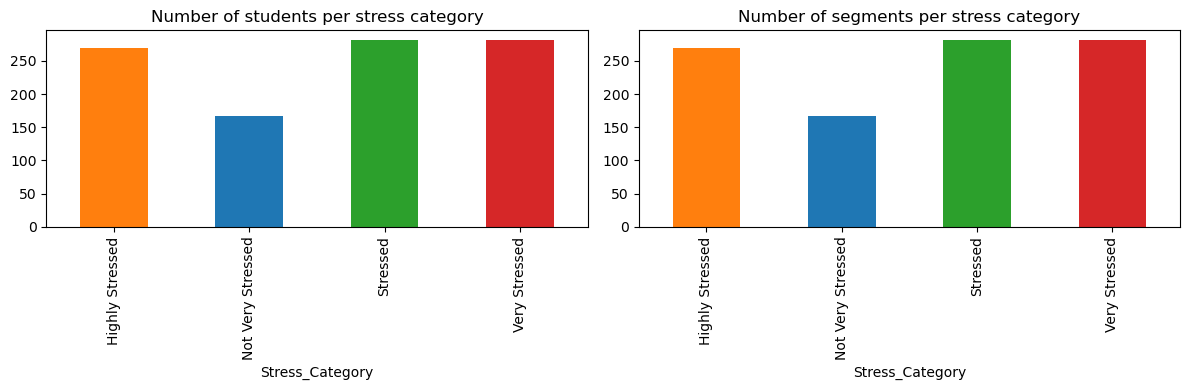

In [6]:
import matplotlib.pyplot as plt

# Display the number of unique students in the train set
print(f"There are {X_df['Student_ID'].nunique()} unique students in the train set.")

# Display the number of students/segments for each stress category
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Number of unique students per stress category
X_df.groupby("Stress_Category")['Student_ID'].apply(lambda x: x.nunique()).plot.bar(
    ax=axes[0], color=["C1", "C0", "C2", "C3"], title="Number of students per stress category"
)

# Number of segments per stress category
X_df.groupby("Stress_Category").size().plot.bar(
    ax=axes[1], color=["C1", "C0", "C2", "C3"], title="Number of segments per stress category"
)

plt.tight_layout()
plt.show()


We now look at the demographic information of the patients:

#### Demographic Information of the Students
To analyze the demographic information of the students, we can look at the distribution of age and gender in the dataset.


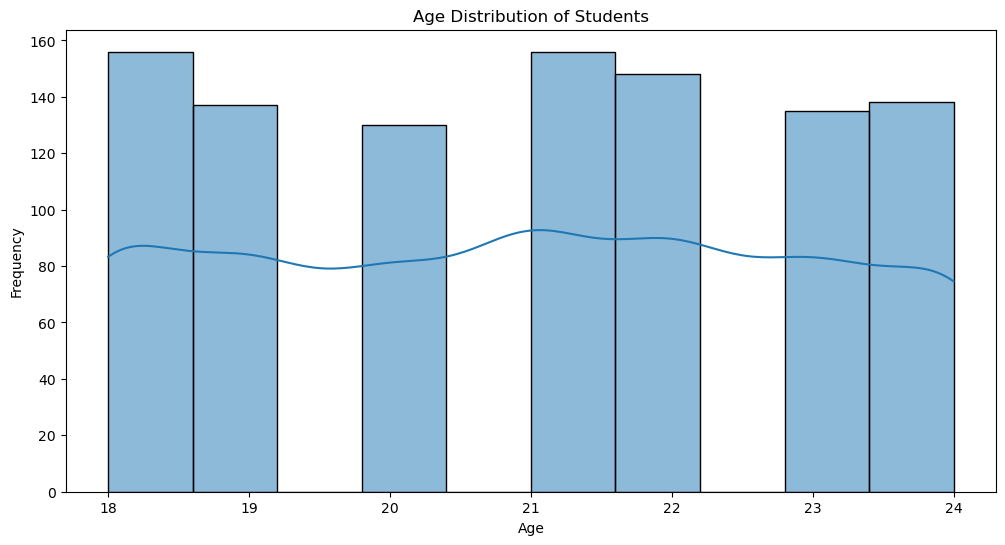

/var/folders/0y/3pk_5p015g58rlb1_90dw_qh0000gn/T/ipykernel_98470/2164810186.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=X_df, palette='Set2')


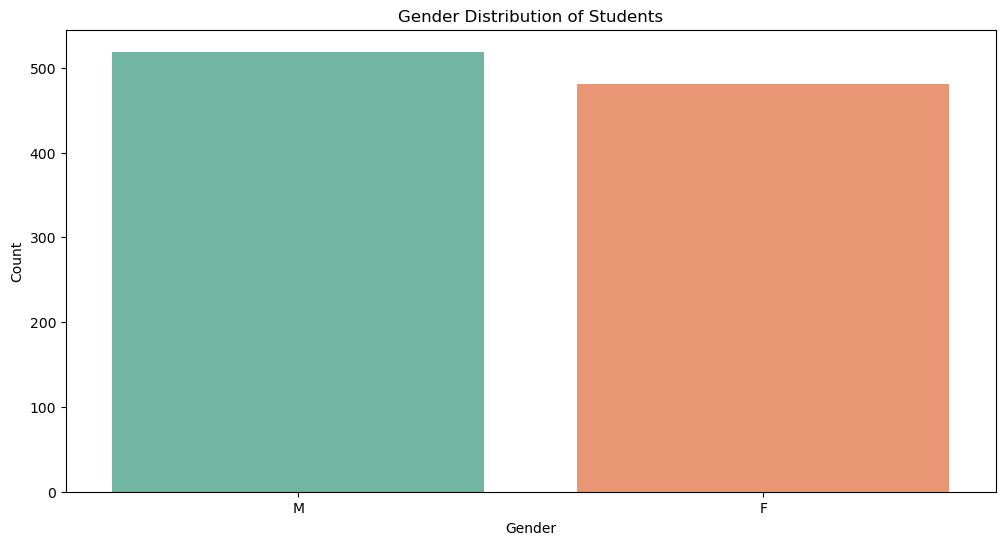

/var/folders/0y/3pk_5p015g58rlb1_90dw_qh0000gn/T/ipykernel_98470/2164810186.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='Age', data=X_df, palette='Set2')


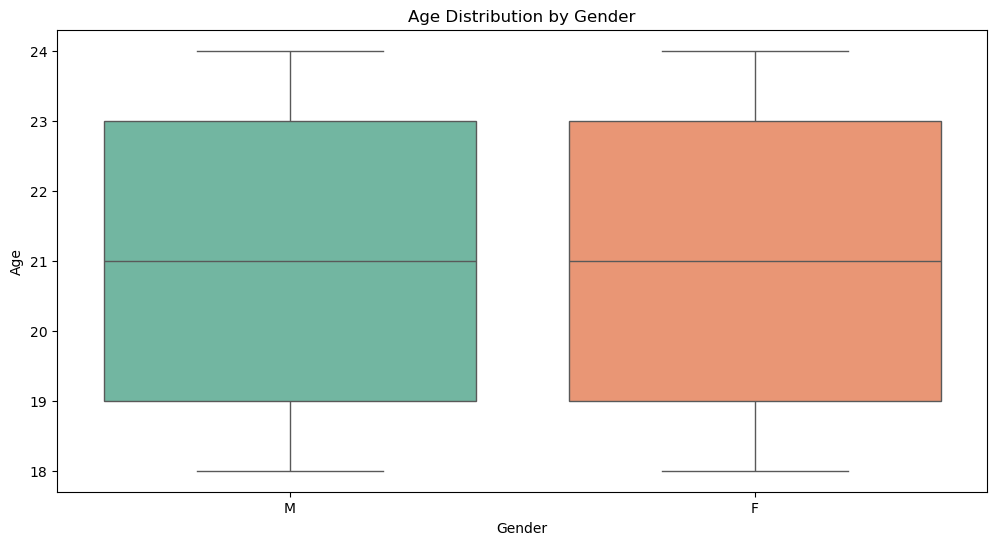

In [7]:
import seaborn as sns

# Display the distribution of age
plt.figure(figsize=(12, 6))
sns.histplot(X_df['Age'], bins=10, kde=True, color='C0')
plt.title('Age Distribution of Students')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Display the distribution of gender
plt.figure(figsize=(12, 6))
sns.countplot(x='Gender', data=X_df, palette='Set2')
plt.title('Gender Distribution of Students')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

# Display the distribution of age by gender
plt.figure(figsize=(12, 6))
sns.boxplot(x='Gender', y='Age', data=X_df, palette='Set2')
plt.title('Age Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Age')
plt.show()


We see here that ... [à compléter]

- Age Distribution: A histogram showing the distribution of ages among the students.
- Gender Distribution: A count plot showing the number of students of each gender.
- Age Distribution by Gender: A box plot showing the distribution of ages for each gender.
These visualizations help in understanding the demographic characteristics of the students in the dataset.

# Challenge evaluation

For this challenge, the metric used to evaluate the performance of the model is the mean absolute error (MAE) between the predicted MAP and the true MAP, defined as:

$$
MAE = \frac{1}{n} \sum_{i=1}^{n} |y_{pred}^i - y_{true}^i|
$$

Here, we take the MAE over the test set, which is composed of signals coming
from domain `m`.

### A first model without the waveforms

We can start by building a simple model without the waveforms to see how well we can predict the MAP from the demographic information and the low-frequency signals.

In [10]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge


from sklearn import set_config
set_config(transform_output="pandas")

from sklearn.metrics import mean_absolute_error


X_df, y = problem_pau.get_train_data(load_waveform=False)
X_df_test, y_test = problem_pau.get_test_data(load_waveform=False)



class IgnoreAdapter(RandomForestRegressor):
    def fit(self, X, y):
        X = X[~y.isna()]
        y = y[~y.isna()]
        return super().fit(X, y)

    def predict(self, X):
        return super().predict(X.drop(columns=["domain"]))


clf = make_pipeline(
    make_column_transformer(
        ("passthrough", ["Age"]),
        (OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ["Gender"]),
    ),
    RandomForestRegressor(n_estimators=50)
    # Ridge(alpha=1)
)
clf.fit(X_df, y)
print(f"Score on train: {mean_absolute_error(clf.predict(X_df), y)}")
print(f"Score on test: {mean_absolute_error(clf.predict(X_df_test), y_test)}")

Score on train: 2.223072797038186
Score on test: 2.223072797038186


# Submission format

Here, you should describe the submission format. This is the format the participants should follow to submit their predictions on the RAMP plateform.

This section also show how to use the `ramp-workflow` library to test the submission locally.

## The pipeline workflow

The input data are stored in a dataframe. To go from a dataframe to a numpy array we will use a scikit-learn column transformer. The first example we will write will just consist in selecting a subset of columns we want to work with.

In [13]:
# %load submissions/starting_kit/estimator.py

from sklearn import set_config
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder

set_config(transform_output="pandas")


class IgnoreDomain(RandomForestRegressor):
    def fit(self, X, y):
        # Ignore the samples with missing target
        X = X[y != -1]
        y = y[y != -1]
        return super().fit(X, y)


def get_estimator():
    return make_pipeline(
        make_column_transformer(
            ("passthrough", ["Age"]),
            (OrdinalEncoder(
                handle_unknown='use_encoded_value', unknown_value=-1
            ), ["Gender"]),
        ),
        IgnoreDomain(n_estimators=50)
    )


## Testing using a scikit-learn pipeline

In [14]:
from sklearn.model_selection import cross_val_score

X_df, y = problem_pau.get_train_data()

scores = cross_val_score(get_estimator(), X_df, y, cv=5, scoring='neg_mean_absolute_error')
print(scores)

[-2.11513149 -2.2479198  -2.25193911 -2.27197007 -2.38828544]


In [15]:
X_test, y_test = problem_pau.get_test_data()

In [16]:
X_test.head()

,Student_ID,Age,Gender,Heart_Rate,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Physical_Activity,Sleep_Quality,Mood,Study_Hours,Project_Hours,Health_Risk_Level,Stress_Category
0,1,24,M,50.663217,122.173015,84.419860,High,Moderate,Happy,34.520973,16.800956,Moderate,Stressed
1,2,21,F,57.926042,110.778407,75.696145,Moderate,Good,Stressed,16.763846,15.791154,Moderate,Stressed
2,3,22,M,59.294219,109.375673,83.803814,Low,Moderate,Happy,44.203798,25.678437,Moderate,Very Stressed
3,4,24,M,76.826232,125.142227,78.091587,High,Poor,Happy,21.776645,20.808391,High,Very Stressed
4,5,20,M,68.342769,107.515592,80.674937,Moderate,Poor,Happy,8.964999,15.194045,Moderate,Very Stressed


In [17]:
X_df.head()

,Student_ID,Age,Gender,Heart_Rate,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Physical_Activity,Sleep_Quality,Mood,Study_Hours,Project_Hours,Health_Risk_Level,Stress_Category
0,1,24,M,50.663217,122.173015,84.419860,High,Moderate,Happy,34.520973,16.800956,Moderate,Stressed
1,2,21,F,57.926042,110.778407,75.696145,Moderate,Good,Stressed,16.763846,15.791154,Moderate,Stressed
2,3,22,M,59.294219,109.375673,83.803814,Low,Moderate,Happy,44.203798,25.678437,Moderate,Very Stressed
3,4,24,M,76.826232,125.142227,78.091587,High,Poor,Happy,21.776645,20.808391,High,Very Stressed
4,5,20,M,68.342769,107.515592,80.674937,Moderate,Poor,Happy,8.964999,15.194045,Moderate,Very Stressed


In [18]:
X_df.columns

Index(['Student_ID', 'Age', 'Gender', 'Heart_Rate', 'Blood_Pressure_Systolic',
       'Blood_Pressure_Diastolic', 'Physical_Activity', 'Sleep_Quality',
       'Mood', 'Study_Hours', 'Project_Hours', 'Health_Risk_Level',
       'Stress_Category'],
      dtype='object')

## Submission

To submit your code, you can refer to the [online documentation](https://paris-saclay-cds.github.io/ramp-docs/ramp-workflow/stable/using_kits.html).